In [1]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

In [2]:
# data
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

deep_bn = nn.Sequential(
    nn.Linear(512, 256), nn.BatchNorm1d(256), nn.SiLU(), nn.Dropout(0.3),
    nn.Linear(256, 128), nn.BatchNorm1d(128), nn.SiLU(), nn.Dropout(0.3),
    nn.Linear(128, 9)
)

# base

In [3]:
res_mod = models.resnet18(weights='IMAGENET1K_V1')

for name, child in res_mod.named_children():
    if name == 'fc':
        print(name + ' has been unfrozen.')
        for param in child.parameters():
            param.requires_grad = True
    else:
        for param in child.parameters():
            param.requires_grad = False

res_mod.fc = deep_bn

res_mod = res_mod.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_silu_bn = torch.optim.AdamW(filter(lambda x: x.requires_grad, res_mod.parameters()), lr=3e-4,
                                   weight_decay=3e-5)
scheduler_silu_bn = lr_scheduler.CosineAnnealingLR(optimizer_silu_bn, T_max=30, eta_min=1e-6)
deep_silu_bn, metrics_silu_bn = train_model(res_mod, criterion, optimizer_silu_bn, scheduler_silu_bn, dataloaders,
                                          dataset_sizes, 25)

val Loss: 0.9365 | Acc: 0.6564 | Weighted Acc: 0.6148 | F1-macro: 0.6586 | Top-1 Acc: 0.6564 | Top-3 Acc: 0.9210
Epoch Time: 19.2096s

Training complete in 8m 10s
Best val Weighted Acc: 0.632586 | Best F1-score: 0.6753 | Best Top-1 Acc: 0.6735 | Best Top-3 Acc: 0.9218


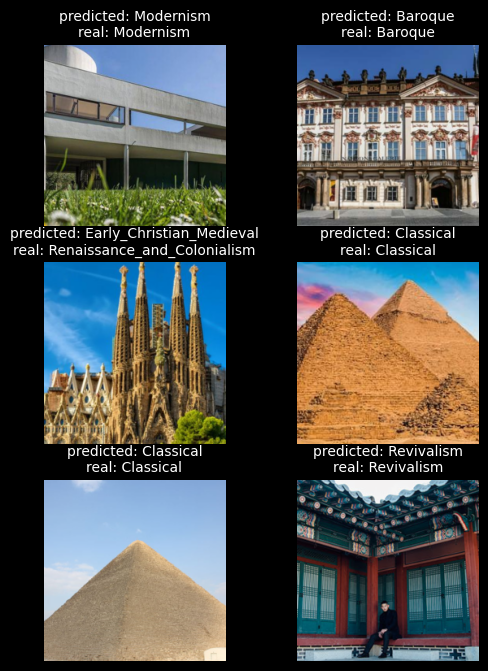

In [4]:
visualize_model(deep_silu_bn, num_images=6, class_names=class_names, vis_loader=vis_loader)

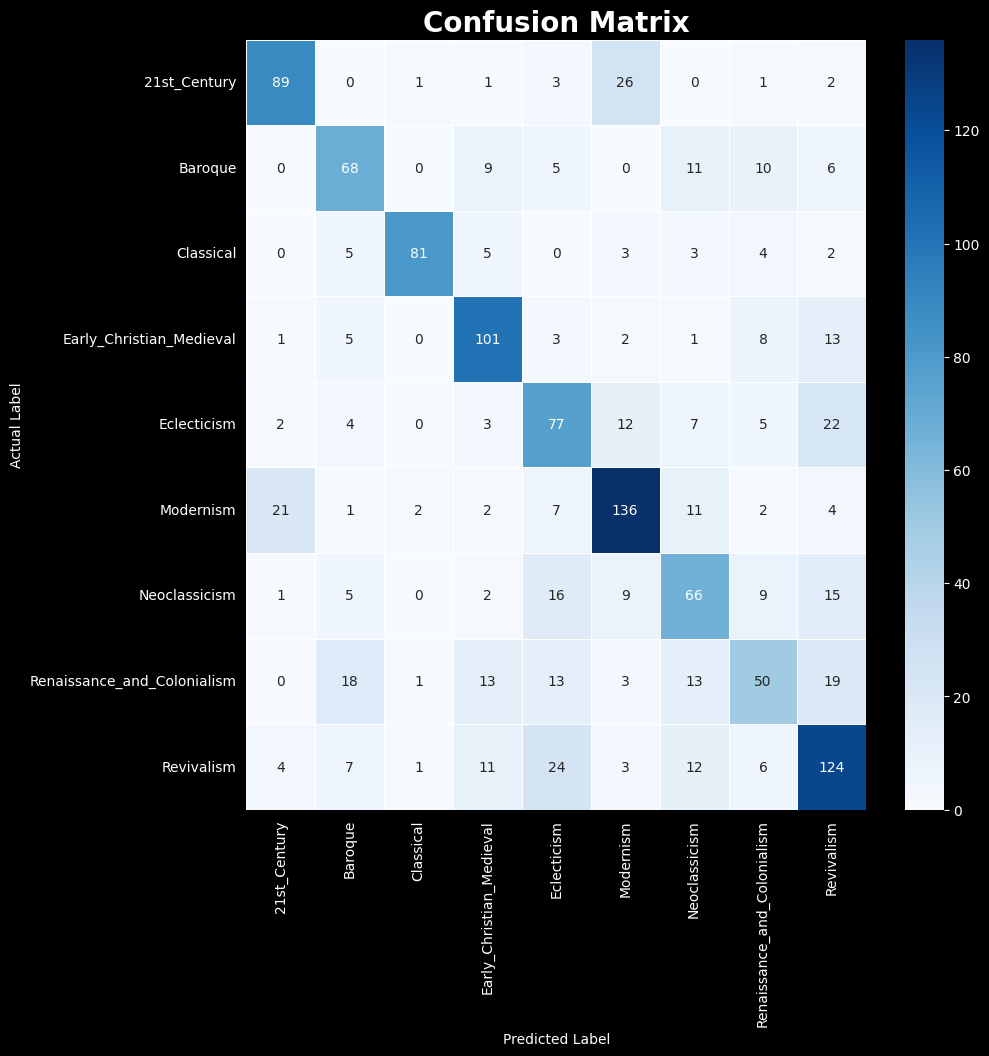

In [5]:
visualize_cm(deep_silu_bn, class_names, test_set)

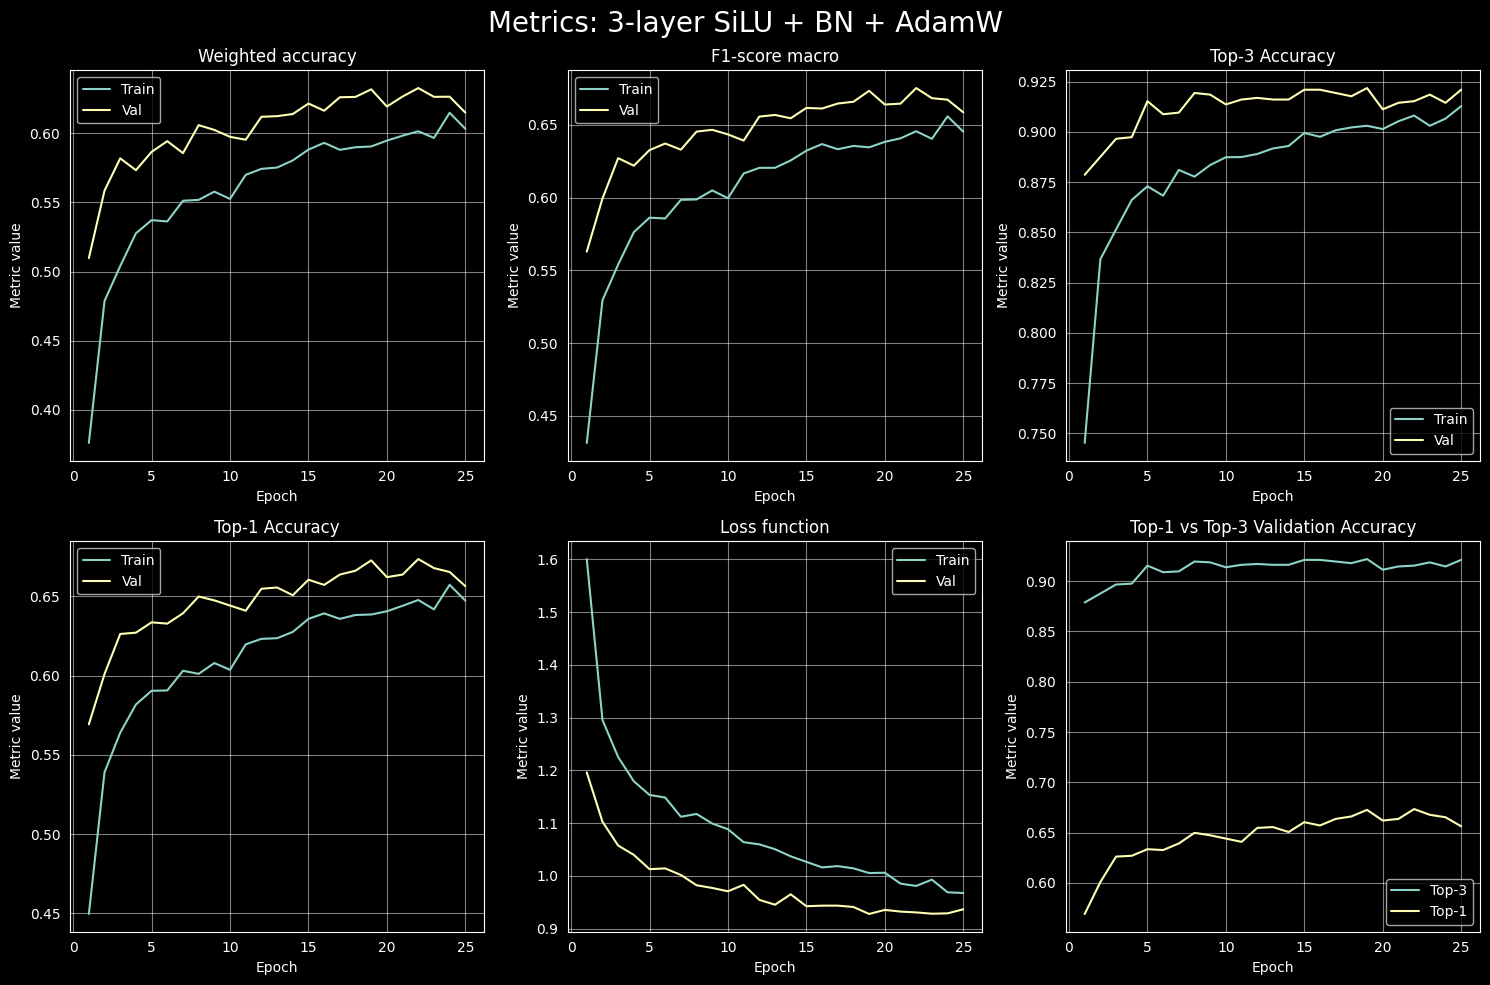

In [6]:
visualize_metrics(metrics_silu_bn, "Metrics: 3-layer SiLU + BN + AdamW", 25)

# fine tuning 1: lr = 1e-4, weight_decay = 3e-5

In [7]:
cur_mod = deep_silu_bn.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_silu_bn = torch.optim.AdamW(filter(lambda x: x.requires_grad, cur_mod.parameters()), lr=1e-4, weight_decay=3e-5)
scheduler_silu_bn = lr_scheduler.CosineAnnealingLR(optimizer_silu_bn, T_max=30, eta_min=1e-6)

In [8]:
deep_silu_bn_v2, metrics_v2 = train_model(cur_mod, criterion, optimizer_silu_bn, scheduler_silu_bn, dataloaders, dataset_sizes, 25)

val Loss: 0.9003 | Acc: 0.6832 | Weighted Acc: 0.6420 | F1-macro: 0.6823 | Top-1 Acc: 0.6832 | Top-3 Acc: 0.9275
Epoch Time: 19.8045s

Training complete in 8m 9s
Best val Weighted Acc: 0.643805 | Best F1-score: 0.6843 | Best Top-1 Acc: 0.6840 | Best Top-3 Acc: 0.9251


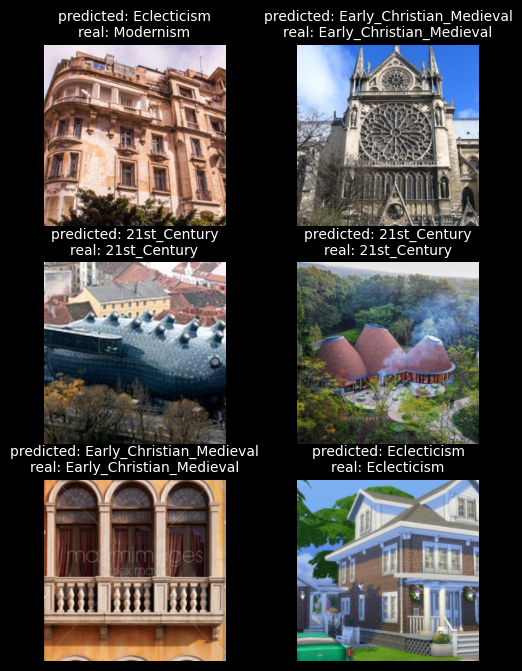

In [9]:
visualize_model(deep_silu_bn_v2, num_images=6, class_names=class_names, vis_loader=vis_loader)

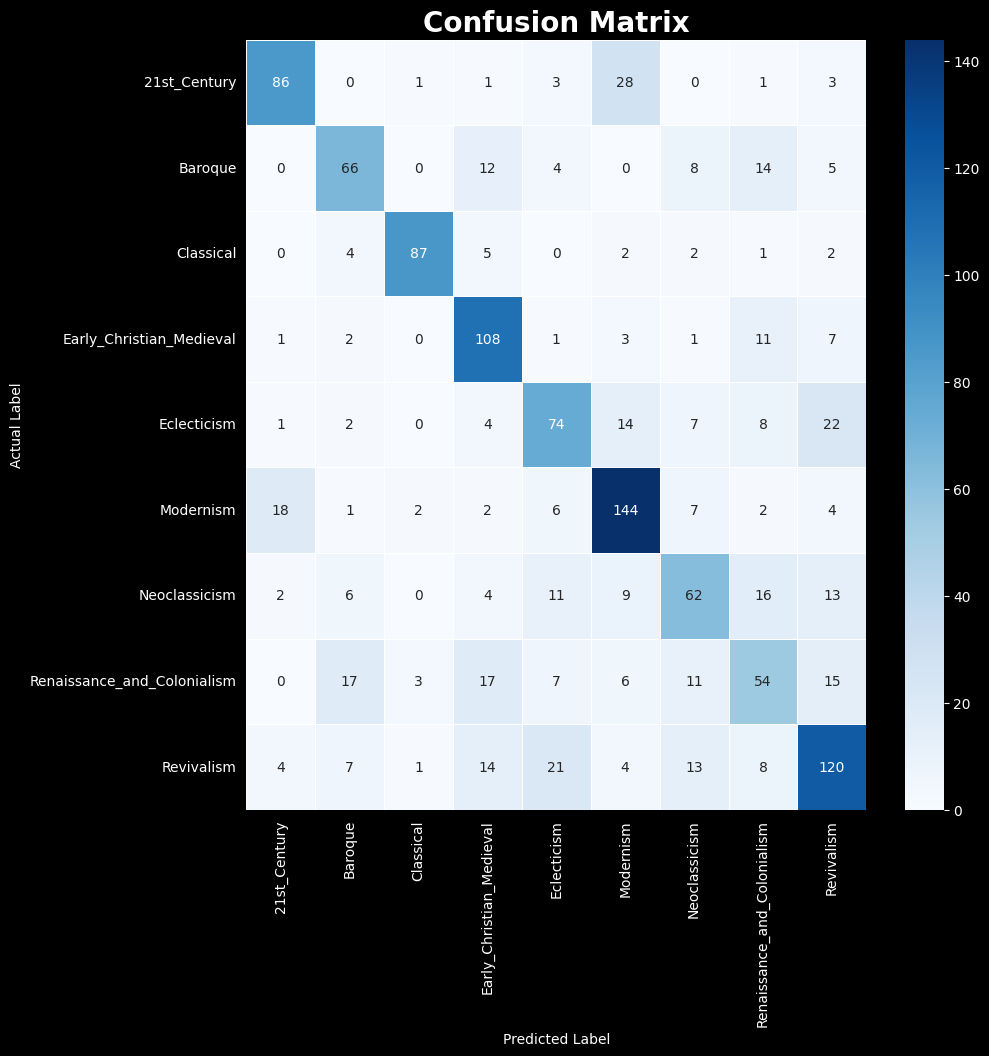

In [10]:
visualize_cm(deep_silu_bn_v2, class_names, test_set)

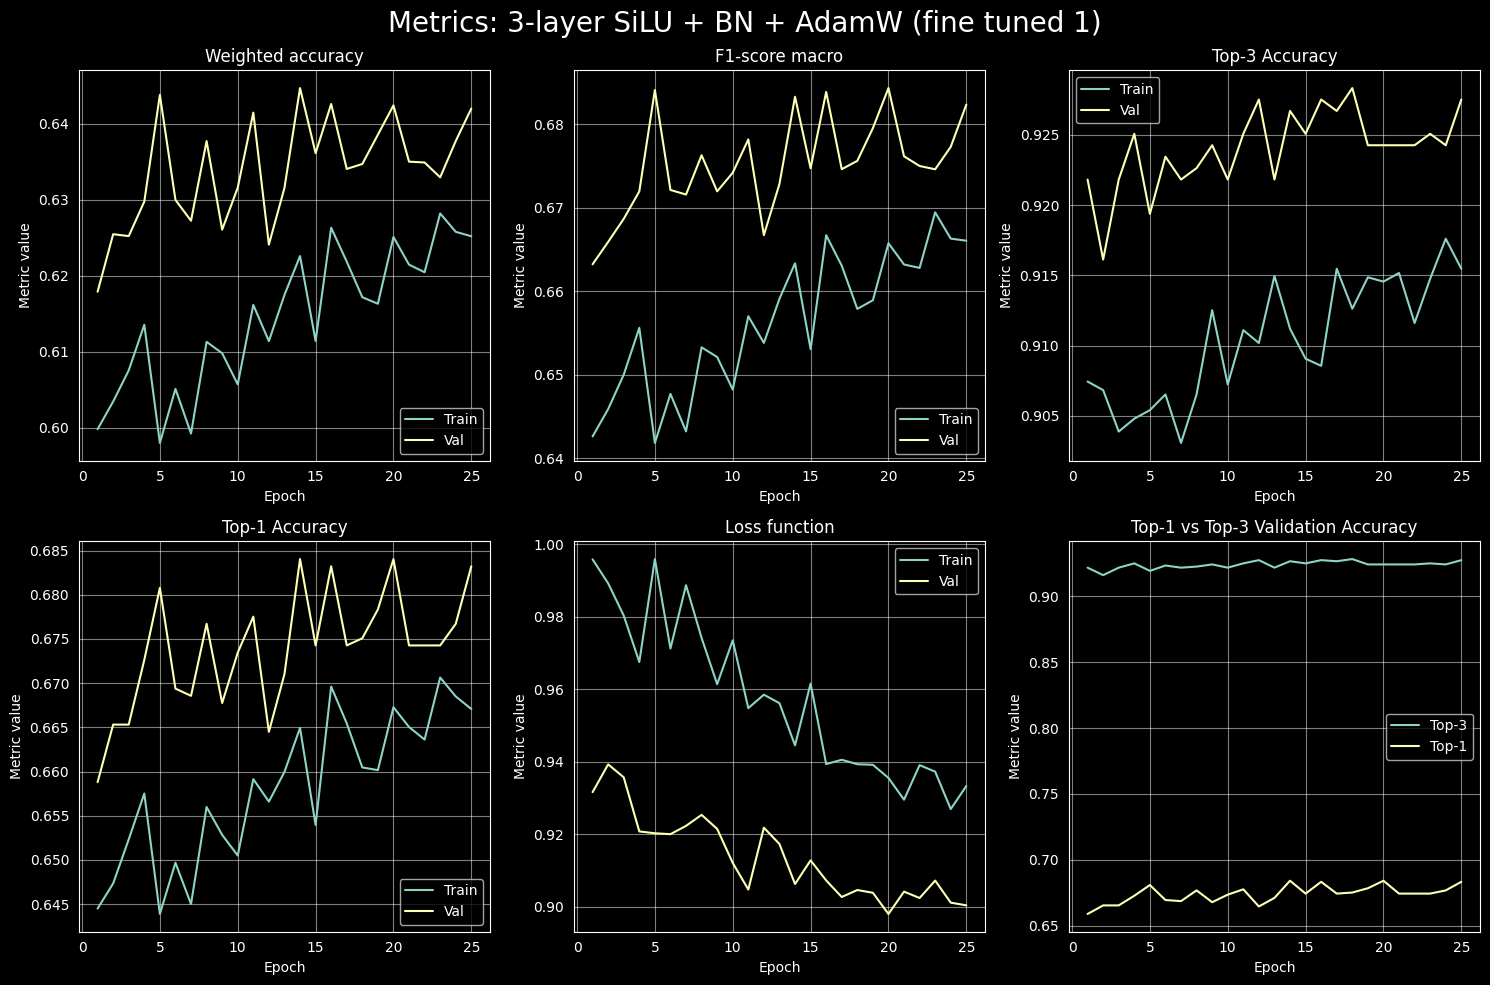

In [11]:
visualize_metrics(metrics_v2, "Metrics: 3-layer SiLU + BN + AdamW (fine tuned 1)", 25)

# fine tuning 2: lr=3e-5, weight_decay=3e-5

In [12]:
cur_mod = deep_silu_bn_v2.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_silu_bn = torch.optim.AdamW(filter(lambda x: x.requires_grad, cur_mod.parameters()), lr=3e-5,
                                      weight_decay=3e-5)
scheduler_silu_bn = lr_scheduler.CosineAnnealingLR(optimizer_silu_bn, T_max=30, eta_min=1e-6)
deep_silu_bn_v3, metrics_v3 = train_model(cur_mod, criterion, optimizer_silu_bn, scheduler_silu_bn, dataloaders,
                                          dataset_sizes, 25)

val Loss: 0.8981 | Acc: 0.6767 | Weighted Acc: 0.6359 | F1-macro: 0.6771 | Top-1 Acc: 0.6767 | Top-3 Acc: 0.9283
Epoch Time: 19.8639s

Training complete in 8m 11s
Best val Weighted Acc: 0.645588 | Best F1-score: 0.6855 | Best Top-1 Acc: 0.6832 | Best Top-3 Acc: 0.9267


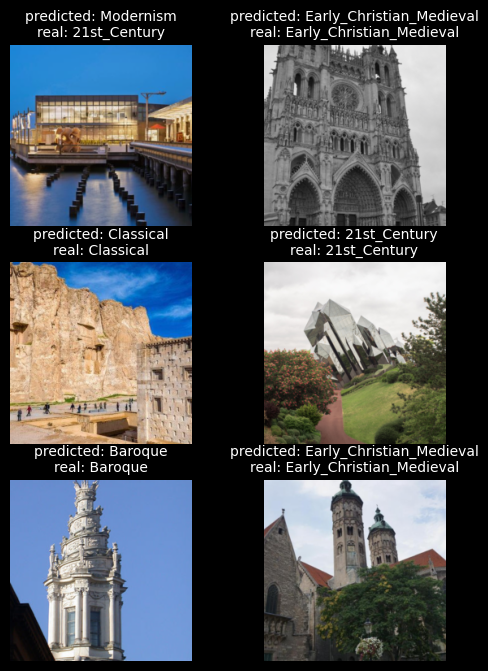

In [13]:
visualize_model(deep_silu_bn_v3, num_images=6, class_names=class_names, vis_loader=vis_loader)

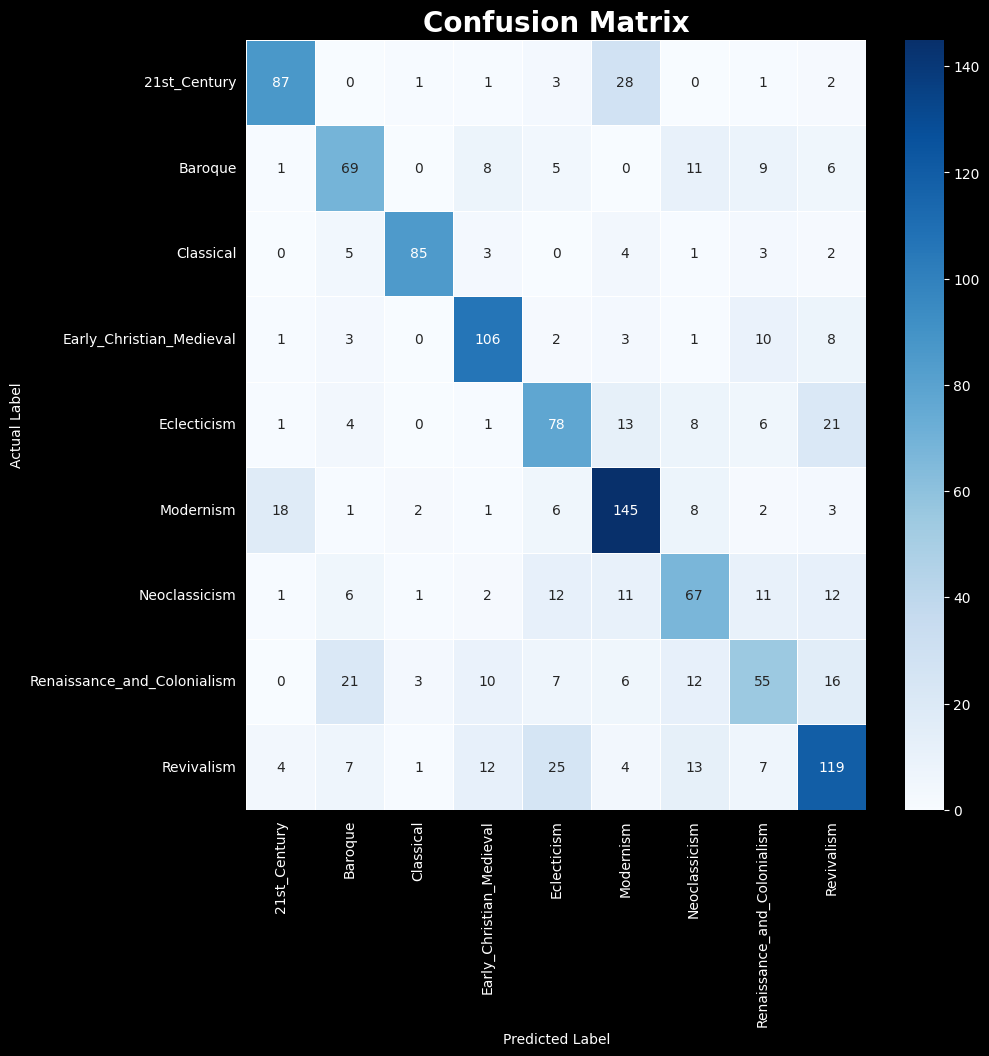

In [14]:
visualize_cm(deep_silu_bn_v3, class_names, test_set)

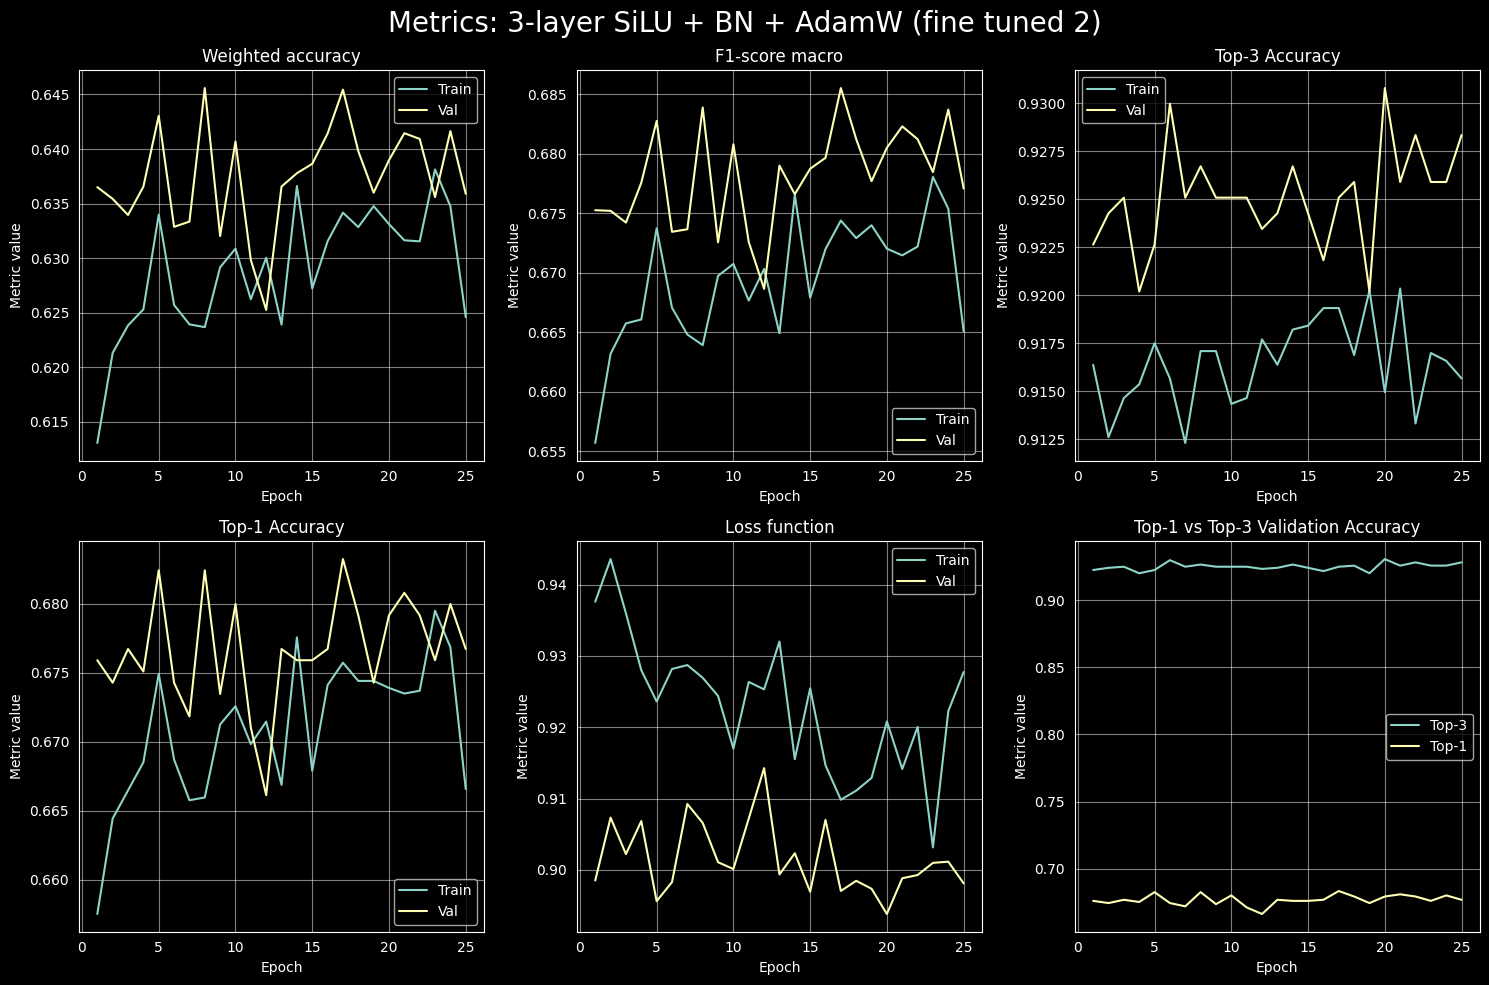

In [15]:
visualize_metrics(metrics_v3, "Metrics: 3-layer SiLU + BN + AdamW (fine tuned 2)", 25)

In [21]:
torch.save(deep_silu_bn_v3, 'best_deep_silu_bn_v3.pt')

# fine tuning 3: lr = 1e-4, weight_decay = 1e-4

In [16]:
cur_mod = deep_silu_bn_v3.to(device)

optimizer_final = torch.optim.AdamW(
    filter(lambda x: x.requires_grad, cur_mod.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)
scheduler_final = lr_scheduler.CosineAnnealingLR(optimizer_final, T_max=30, eta_min=1e-7)

deep_silu_bn_v4, metrics_v4 = train_model(cur_mod, criterion, optimizer_final,
                                        scheduler_final, dataloaders, dataset_sizes, 30)

val Loss: 0.8970 | Acc: 0.6832 | Weighted Acc: 0.6415 | F1-macro: 0.6843 | Top-1 Acc: 0.6832 | Top-3 Acc: 0.9283
Epoch Time: 19.6427s

Training complete in 9m 46s
Best val Weighted Acc: 0.644013 | Best F1-score: 0.6855 | Best Top-1 Acc: 0.6824 | Best Top-3 Acc: 0.9316


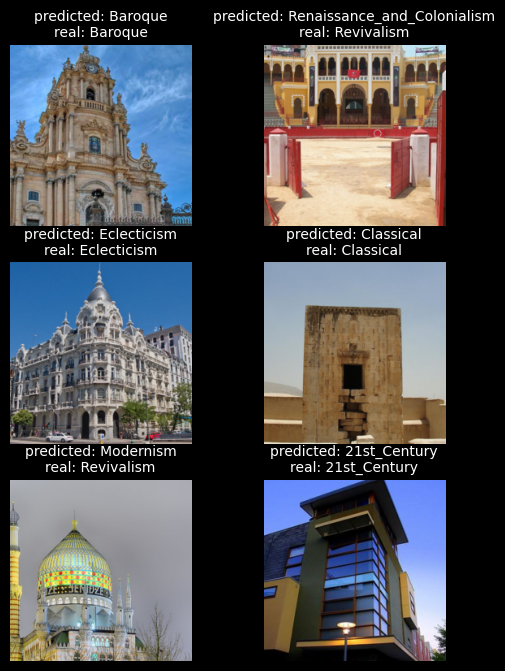

In [17]:
visualize_model(deep_silu_bn_v4, num_images=6, class_names=class_names, vis_loader=vis_loader)

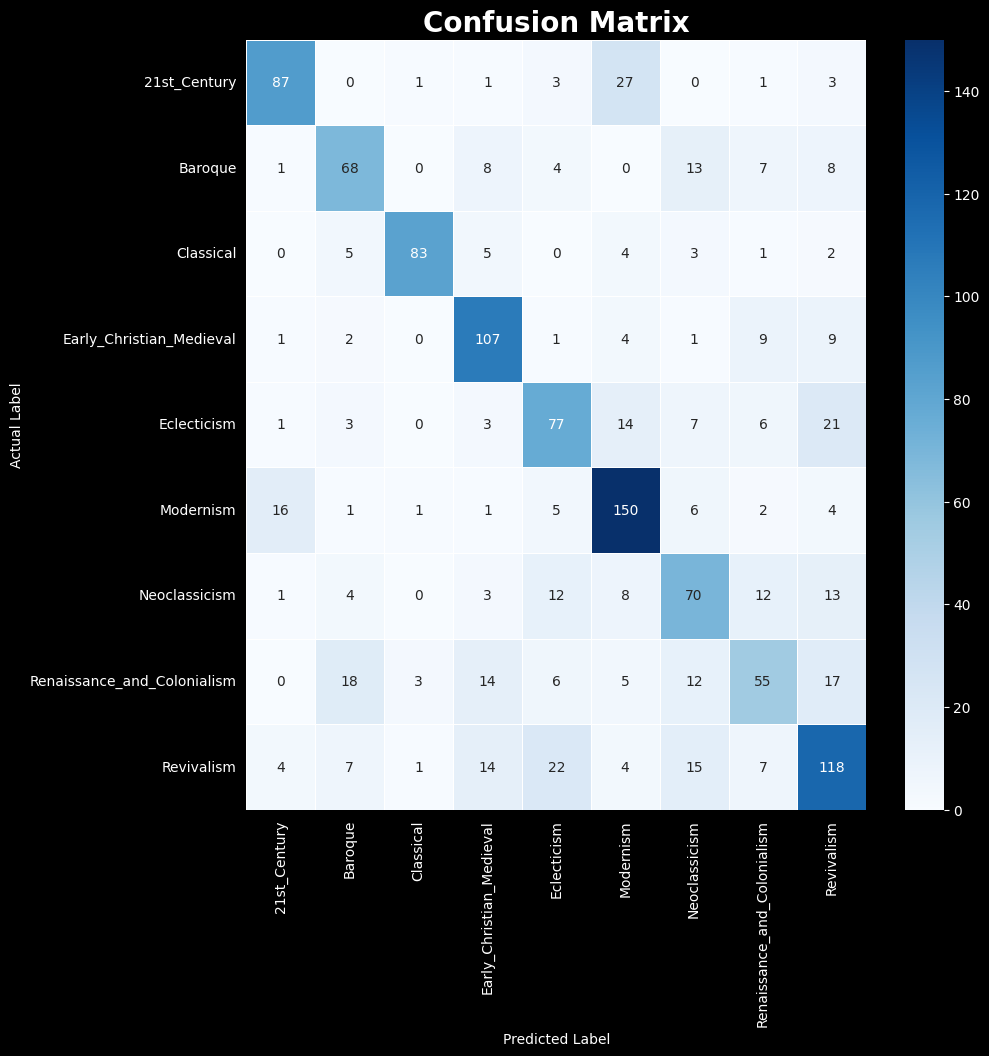

In [18]:
visualize_cm(deep_silu_bn_v4, class_names, test_set)

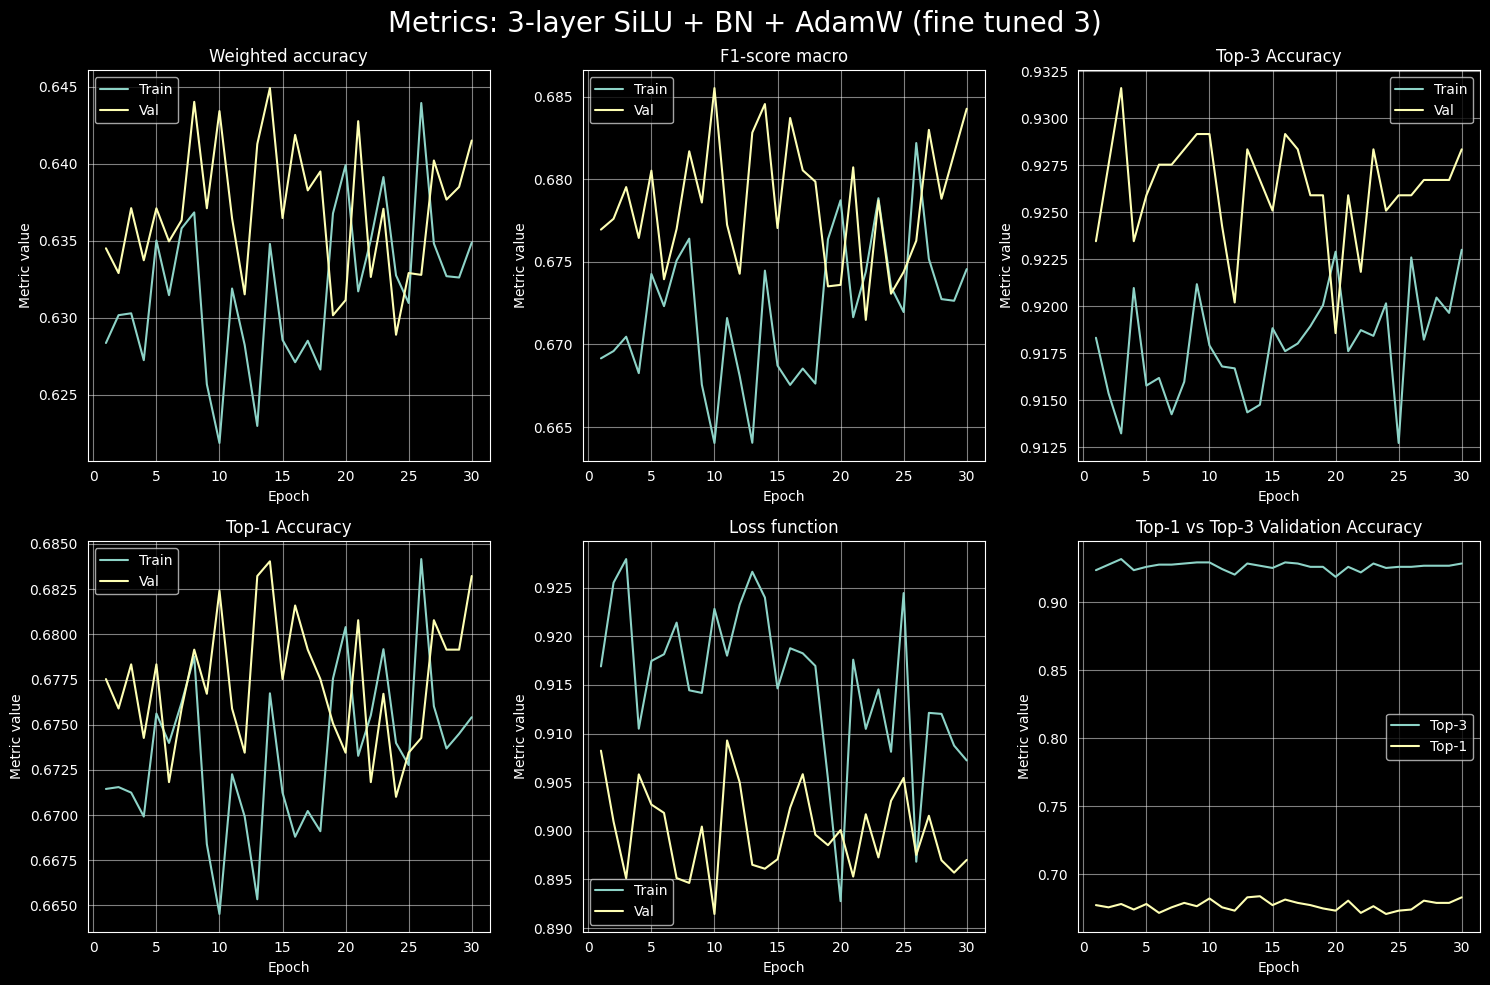

In [20]:
visualize_metrics(metrics_v4, "Metrics: 3-layer SiLU + BN + AdamW (fine tuned 3)", 30)